In [3]:
# 1) Build your static product
from custom_importer  import create_product_static_from_dict
from pricers          import create_pricer
from datetime         import date
from dateutil.relativedelta import relativedelta
import numpy as np
    
option_config = {
    "module_name":     "product_definitions",
    "product_type":    "EuropeanOptionStatic",
    "valuation_date":  date.today().isoformat(),
    "expiry_date":     (date.today()+relativedelta(years=1)).isoformat(),
    "strike_price":    150.0,
    "option_type":     "call",
    "currency":        "USD",
    "underlying_symbol": "AAPL"
}
static_opt = create_product_static_from_dict(option_config)

# 2) Build your pricer _instance_
pricer_cfg = {
    "pricer_module_name": "black_scholes_pricer",
    "pricer_class_name":  "BlackScholesPricer",
    "pricer_params": {
    }
}
opt_pricer = create_pricer(static_opt, pricer_cfg)

price0 = opt_pricer.price(160.0, 0.2, risk_free_rate=0.01, dividend_yield=0.02)
print("single‐scenario price:", price0)

#   Or arrays
S_arr   = [150.0,160.0,170.0]
vol_arr = [0.2,0.25,0.3]
print("vectorized prices:", opt_pricer.price(S_arr, vol_arr, risk_free_rate=0.01, dividend_yield=0.02))

single‐scenario price: 16.770896790033362
vectorized prices: [11.04643458 19.70716565 29.20661054]


In [4]:
# 1) Build your static product
bond_config = {
    "module_name":     "product_definitions",
    "product_type":    "QuantLibBondStaticBase",
    "valuation_date":  date.today().isoformat(),
    "maturity_date":   (date.today()+relativedelta(years=5)).isoformat(),
    "face_value":      100.0,
    "coupon_rate":     0.05,
    "currency":        "USD"
}
static_bond = create_product_static_from_dict(bond_config)

# 2) Build your pricer _instance_
pricer_cfg = {
    "pricer_module_name": "quantlib_bond_pricer",
    "pricer_class_name":  "QuantLibBondPricer",
    "pricer_params": {
    }
}
bond_pricer = create_pricer(static_bond, pricer_cfg)

bond_price = bond_pricer.price(market_scenario_data=np.array([.02, 0.025, 0.03, 0.035, 0.04, 0.045]),
                    pillar_times=np.array([0.5, 1.0, 2.0, 3.0, 4.0, 5.0]))

print("Bond static definition:", static_bond.to_dict())
print("Bond price:", bond_price)

Bond static definition: {'product_type': 'VanillaBond', 'valuation_date': '2025-06-15', 'maturity_date': '2030-06-15', 'coupon_rate': 0.05, 'face_value': 100.0, 'freq': 2, 'settlement_days': 0, 'currency': 'USD', 'index_stub': 'GENERIC_IR', 'credit_spread_curve_name': None, 'calendar': 'TARGET', 'day_count': 'Actual/Actual (ISDA)'}
Bond price: [102.42906969]


In [5]:
# 1) Build your static product
conv_config = {
    "module_name":      "product_definitions",
    "product_type":     "ConvertibleBondStaticBase",
    "valuation_date":   date.today().isoformat(),
    "issue_date":       (date.today() - relativedelta(months=6)).isoformat(),
    "maturity_date":    (date.today() + relativedelta(years=5)).isoformat(),
    "coupon_rate":      0.05,
    "conversion_ratio": 1.0,
    "face_value":       100.0,
    "freq":             2,
    "currency":         "USD",
    "underlying_symbol":"DEMO_STOCK"
}
static_conv = create_product_static_from_dict(conv_config)

# 2) Build your pricer instance for convertible‐binomial method
pricer_cfg = {
    "pricer_module_name": "quantlib_bond_pricer",
    "pricer_class_name":  "QuantLibBondPricer",
    "pricer_params": {
        "method":         "convertible_binomial",
        "convertible_engine_steps": 64
    }
}
conv_pricer = create_pricer(static_conv, pricer_cfg)

# 3) Prepare scenario: risk‐free pillars only and static credit for engine
pillar_times = np.array([0.5,1.0,2.0,3.0,4.0,5.0], dtype=float)
rf_curve     = np.array([[0.02,0.025,0.03,0.035,0.04,0.045]])
S0           = np.linspace(50, 150, 32)  # Underlying prices for the convertible bond

result = []
for S in S0:
    price = conv_pricer.price(
        pillar_times=pillar_times,
        market_scenario_data=rf_curve,
        s0_val=S,
        dividend_yield=0.01,
        equity_volatility=0.20,
        credit_spread=0.015
    )
    result.append(price)

print("Convertible static definition:", static_conv.to_dict())
print("Convertible price:", price)

Convertible static definition: {'product_type': 'ConvertibleBond', 'valuation_date': '2025-06-15', 'maturity_date': '2030-06-15', 'coupon_rate': 0.05, 'face_value': 100.0, 'freq': 2, 'settlement_days': 0, 'currency': 'USD', 'index_stub': 'GENERIC_IR', 'credit_spread_curve_name': None, 'calendar': 'TARGET', 'day_count': 'Actual/Actual (ISDA)', 'issue_date': '2024-12-15', 'conversion_ratio': 1.0, 'exercise_type': 'EuropeanAtMaturity', 'underlying_symbol': 'DEMO_STOCK'}
Convertible price: [164.05106767]


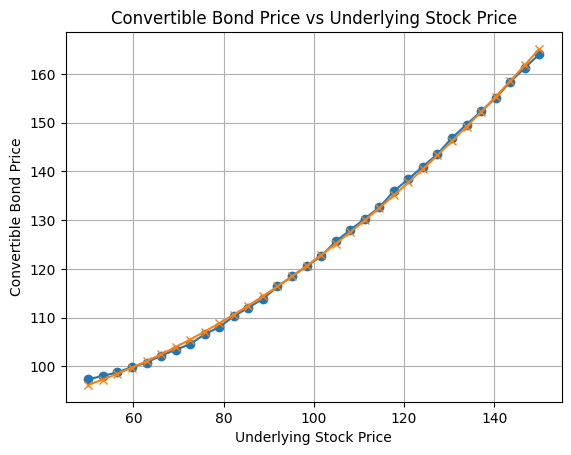

In [6]:
# Do a quadratic fit of the results
from numpy.polynomial import Polynomial
result_flat = np.array(result).flatten()
p = Polynomial.fit(S0, result_flat, 2)
# Evaluate the polynomial fit
result_poly = p(S0)

# Plot stock price vs convertible price vs fitted polynomial
import matplotlib.pyplot as plt
plt.plot(S0, result, marker='o', label='Convertible Bond Price')
plt.plot(S0, result_poly, marker='x', label='Fitted Polynomial')
plt.title("Convertible Bond Price vs Underlying Stock Price")
plt.xlabel("Underlying Stock Price")
plt.ylabel("Convertible Bond Price")
plt.grid()
plt.show()

In [7]:
c_p = conv_pricer.price(
        pillar_times=pillar_times,
        market_scenario_data=rf_curve,
        s0_val=100,
        dividend_yield=0.01,
        equity_volatility=0.20,
        credit_spread=0.015
    )

p(100), c_p


(np.float64(121.72872793837168), array([121.57507494]))

Callable Bond Base Price at zero shift: [102.56426971]
Callable Bond polynomial fit at zero shift: 102.56494775309909


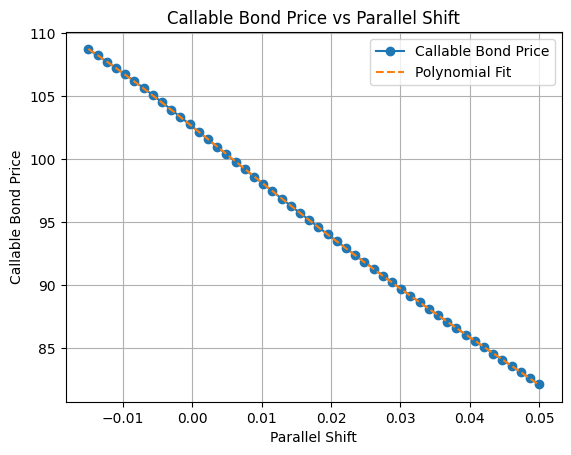

In [8]:
# 1) Build your static product
callable_bond_config = {
    "module_name":     "product_definitions",
    "product_type":    "CallableBondStaticBase",
    "valuation_date":  date.today().isoformat(),
    "maturity_date":   (date.today()+relativedelta(years=5)).isoformat(),
    "face_value":      100.0,
    "coupon_rate":     0.05,
    "currency":        "USD",
    "call_dates":      [(date.today()+relativedelta(years=3)).isoformat(),
                        (date.today()+relativedelta(years=4)).isoformat()],
    "call_prices":     [100.0, 100.0]
}
static_callable_bond = create_product_static_from_dict(callable_bond_config)

# 2) Build your pricer _instance_
pricer_cfg = {
    "pricer_module_name": "quantlib_bond_pricer",
    "pricer_class_name":  "QuantLibBondPricer",
    "pricer_params": {
        "method": "g2",
        "grid_steps": 64,
    }
}
callable_bond_pricer = create_pricer(static_callable_bond, pricer_cfg)
g2_p = [0.01, 0.003, 0.015, 0.006, -0.75]  # (a,σ,b,η,ρ)
pillar_times   = np.array([0.5,1.0,2.0,3.0,4.0,5.0])
scenarios      = np.array([[0.02,0.025,0.03,0.035,0.04,0.045]])

# do shift of -1.5% to 5% up parallel to scenarios in linspace for 50
shifts = np.linspace(-0.015, 0.05, 50)
# calculate parallel shifts of the scenarios
shifted_scenarios = scenarios + shifts[:, None]
# calculate the callable bond prices for each shifted scenario
shifted_prices = callable_bond_pricer.price(
    pillar_times=pillar_times,
    market_scenario_data=shifted_scenarios,
    g2_params=g2_p
)

# Do a polynomial fit of the results
from numpy.polynomial import Polynomial
p = Polynomial.fit(shifts, shifted_prices, 4)
# Evaluate the polynomial fit
shifted_prices_poly = p(shifts)

# show the base and polynomial fit at zero shift
base_price = callable_bond_pricer.price(
    pillar_times=pillar_times,
    market_scenario_data=scenarios,
    g2_params=g2_p
)
print("Callable Bond Base Price at zero shift:", base_price)
print("Callable Bond polynomial fit at zero shift:", p(0))

# Plot the callable bond price and the polynomial fit
import matplotlib.pyplot as plt
plt.plot(shifts, shifted_prices, marker='o', label='Callable Bond Price')
plt.plot(shifts, shifted_prices_poly, linestyle='--', label='Polynomial Fit')
plt.title("Callable Bond Price vs Parallel Shift")
plt.xlabel("Parallel Shift")
plt.ylabel("Callable Bond Price")
plt.grid()
plt.legend()
plt.show()


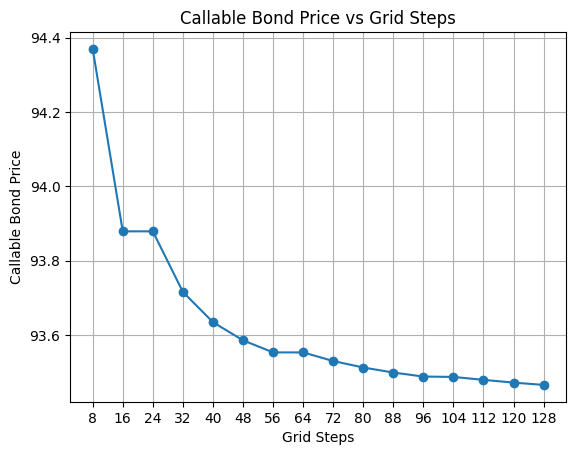

In [9]:
# 1) Build your static product
callable_bond_config = {
    "module_name":     "product_definitions",
    "product_type":    "CallableBondStaticBase",
    "valuation_date":  date.today().isoformat(),
    "maturity_date":   (date.today()+relativedelta(years=5)).isoformat(),
    "face_value":      100.0,
    "coupon_rate":     0.03,
    "currency":        "USD",
    "call_dates":      [(date.today()+relativedelta(years=3)).isoformat(),
                        (date.today()+relativedelta(years=4)).isoformat()],
    "call_prices":     [100.0, 100.0]
}
static_callable_bond = create_product_static_from_dict(callable_bond_config)

g2_p = [0.01, 0.003, 0.015, 0.006, -0.75]  # (a,σ,b,η,ρ)
pillar_times   = np.array([0.5,1.0,2.0,3.0,4.0,5.0])
scenarios      = np.array([[0.02,0.025,0.03,0.035,0.04,0.045]])

results = []
# 2) Build your pricer _instance_ with different grid steps from 8 to 128 in steps of 8
for grid_steps in range(8, 129, 8):
    pricer_cfg = {
        "pricer_module_name": "quantlib_bond_pricer",
        "pricer_class_name":  "QuantLibBondPricer",
        "pricer_params": {
            "method": "g2",
            "grid_steps": grid_steps,
        }
    }
    callable_bond_pricer = create_pricer(static_callable_bond, pricer_cfg)
    price = callable_bond_pricer.price(
        pillar_times=pillar_times,
        market_scenario_data=scenarios,
        g2_params=g2_p
    )
    results.append((grid_steps, price))

# Plot the results
import matplotlib.pyplot as plt
grid_steps, prices = zip(*results)
plt.plot(grid_steps, prices, marker='o')
plt.title("Callable Bond Price vs Grid Steps")
plt.xlabel("Grid Steps")
plt.ylabel("Callable Bond Price")
plt.grid()
plt.xticks(grid_steps)
plt.show()
